# Detect Objects Using Deep Learning

This notebook provides an **interactive workflow** for running the **Detect Objects Using Deep Learning** raster analysis tool via the ArcGIS API for Python. The user drives every step:

1. **Connect** to ArcGIS Online
2. **Provide an Imagery Layer item ID** and add it to a satellite basemap
3. **Zoom / pan** on the map to define the analysis extent
4. **Capture** the current map extent
5. **Provide the deep learning model item ID**
6. **Configure model arguments** dynamically
7. **Run** detect objects and display the results

> **Requirements**: ArcGIS Online organization with Raster Analytics capability enabled, conda env `arcgis-ai`, Python 3.11, `arcgis` 2.4.3.

## Step 1 – Connect to ArcGIS Online

In [1]:
import getpass, urllib3
from arcgis.gis import GIS

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

username = input("ArcGIS Online username: ")
password = getpass.getpass("ArcGIS Online password: ")
gis = GIS("https://www.arcgis.com", username, password, verify_cert=False)
print(f"Signed in as: {gis.users.me.username} ({gis.properties.portalName})")

Setting `verify_cert` to False is a security risk, use at your own risk.


Signed in as: ralouta.aiddev (ArcGIS Online)


## Step 2 – Load Imagery Layer

Enter the **Item ID** of an Imagery Layer (Image Service) from your ArcGIS Online organization. The item will be loaded as an `ImageryLayer`.

Loaded: Luchtfoto 2024 (True Ortho) (Image Service)


<Item title:"Luchtfoto 2024 (True Ortho)" type:Imagery Layer owner:BOOT.Administator>
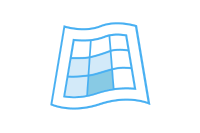

In [2]:
from arcgis.raster import ImageryLayer

#imagery_item_id = input("Enter the Imagery Layer item ID: ")
imagery_item_id = "d45877389571462785065b58b1d00925"
imagery_item = gis.content.get(imagery_item_id)

if imagery_item is None:
    raise ValueError(f"Item '{imagery_item_id}' not found. Check the ID and your permissions.")

# Validate — raster analysis requires an Image Service (ImageServer), not a Map Service (tile cache)
if imagery_item.type not in ("Image Service", "Imagery Layer"):
    raise ValueError(
        f"Item type is '{imagery_item.type}' — raster analysis tools require an Image Service.\n"
        f"A Map Service / tile cache will NOT work. Please provide an Image Service item ID.\n"
        f"Tip: search for the same dataset but look for type='Imagery Layer'."
    )

print(f"Loaded: {imagery_item.title} ({imagery_item.type})")
imagery_item

In [3]:
# Get the imagery layer from the item
# If the item URL is an ImageServer, use it directly.
# If it's a MapServer (tile cache), it won't work for raster analysis.
item_url = imagery_item.url

if "ImageServer" in item_url:
    imagery_layer = ImageryLayer(item_url, gis=gis)
elif imagery_item.type in ("Image Service", "Imagery Layer"):
    imagery_layer = ImageryLayer(item_url, gis=gis)
else:
    raise ValueError(
        f"Item URL is '{item_url}' (type: {imagery_item.type}).\n"
        f"Raster analysis requires an Image Service (ImageServer). "
        f"Please use an Imagery Layer item."
    )

print(f"Imagery Layer URL: {imagery_layer.url}")
print(f"Type: {type(imagery_layer).__name__}")

Imagery Layer URL: https://utility.arcgis.com/usrsvcs/servers/d45877389571462785065b58b1d00925/rest/services/Dynamisch/Ortho/ImageServer
Type: ImageryLayer


## Step 3 – Display Map with Satellite Basemap

A map widget is rendered with a **satellite basemap**. The imagery layer is added on top. **Zoom and pan** to the area you want to analyze — the current extent will be captured in the next step.

In [4]:
m = gis.map()
m.basemap.basemap = "satellite"

# Add the imagery layer to the map
m.content.add(imagery_layer)

# Zoom to the imagery layer's default extent
m.extent = dict(imagery_layer.properties.extent)

m

Map()

## Step 4 – Capture the Analysis Extent

After zooming to your area of interest on the map above, run this cell to capture the current map extent. This extent will constrain the object-detection analysis.p

In [5]:
import json

analysis_extent = m.extent
print("Captured extent:")
print(json.dumps(analysis_extent, indent=2))

Captured extent:
{
  "spatialReference": {
    "latestWkid": 3857,
    "wkid": 102100
  },
  "xmin": 484754.7448804999,
  "ymin": 6813429.09462522,
  "xmax": 486947.53212948865,
  "ymax": 6814862.288905604
}


## Step 5 – Load the Deep Learning Model

Enter the **Item ID** of a deep learning model package (`.dlpk`) published to your ArcGIS Online organization. The model item will be passed to the Detect Objects tool.

Model: Segment Anything Model 3 (SAM3)  (Deep Learning Package)


<Item title:"Segment Anything Model 3 (SAM3) " type:Deep Learning Package owner:eaglegis>
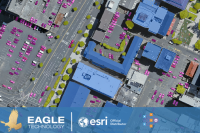

In [6]:
# model_item_id = input("Enter the Deep Learning Model item ID: ")
model_item_id = "37ef2e1ba0c042ce99501f56295ec0d4"
model_item = gis.content.get(model_item_id)

if model_item is None:
    raise ValueError(f"Model item '{model_item_id}' not found. Check the ID and your permissions.")

print(f"Model: {model_item.title} ({model_item.type})")
model_item

## Step 6 – Configure Model Arguments

The model's parameters are automatically extracted from the DLPK using HTTP range requests (no full download needed). Edit the values in the table below, then run the next cell to apply your changes.

In [7]:
import struct, io, json, re, ast, zlib, requests

# ---------------------------------------------------------------------------
# Extract model arguments from the DLPK using HTTP range requests.
# Only a few KB are downloaded (~300 KB) instead of the full multi-GB package.
# ---------------------------------------------------------------------------

token = gis._con.token
data_url = (
    f"https://www.arcgis.com/sharing/rest/content/items/{model_item.itemid}/data"
    f"?token={token}"
)

def _range_get(url, start, end):
    r = requests.get(url, headers={"Range": f"bytes={start}-{end}"}, stream=True, timeout=30)
    r.raise_for_status()
    return r.content

def _read_zip_entry(url, offset, comp_size, uncomp_size, compression):
    header = _range_get(url, offset, offset + 29)
    fname_len = struct.unpack_from("<H", header, 26)[0]
    extra_len = struct.unpack_from("<H", header, 28)[0]
    data_start = offset + 30 + fname_len + extra_len
    raw = _range_get(url, data_start, data_start + comp_size - 1)
    if compression == 0:
        return raw
    elif compression == 8:
        return zlib.decompress(raw, -zlib.MAX_WBITS)
    raise ValueError(f"Unsupported compression: {compression}")

# 1. Get file size
head = requests.head(data_url, allow_redirects=True, timeout=15)
file_size = int(head.headers["Content-Length"])

# 2. Read zip central directory from the tail of the file
tail_size = min(262_144, file_size)
tail = _range_get(data_url, file_size - tail_size, file_size - 1)
eocd_pos = tail.rfind(b"\x50\x4b\x05\x06")
cd_size = struct.unpack_from("<I", tail, eocd_pos + 12)[0]
cd_offset = struct.unpack_from("<I", tail, eocd_pos + 16)[0]

cd_start_in_tail = cd_offset - (file_size - tail_size)
cd_data = tail[cd_start_in_tail:cd_start_in_tail + cd_size] if cd_start_in_tail >= 0 else _range_get(data_url, cd_offset, cd_offset + cd_size - 1)

# 3. Parse central directory to find .emd and .py files
entries = {}
pos = 0
while pos < len(cd_data):
    if cd_data[pos:pos + 4] != b"\x50\x4b\x01\x02":
        break
    compression = struct.unpack_from("<H", cd_data, pos + 10)[0]
    comp_size = struct.unpack_from("<I", cd_data, pos + 20)[0]
    uncomp_size = struct.unpack_from("<I", cd_data, pos + 24)[0]
    fname_len = struct.unpack_from("<H", cd_data, pos + 28)[0]
    extra_len = struct.unpack_from("<H", cd_data, pos + 30)[0]
    comment_len = struct.unpack_from("<H", cd_data, pos + 32)[0]
    local_offset = struct.unpack_from("<I", cd_data, pos + 42)[0]
    fname = cd_data[pos + 46:pos + 46 + fname_len].decode("utf-8", errors="replace")
    if fname.endswith(".emd") or fname.endswith(".py"):
        entries[fname] = (local_offset, comp_size, uncomp_size, compression)
    pos += 46 + fname_len + extra_len + comment_len

# 4. Read the .emd model definition
emd_name = next(f for f in entries if f.endswith(".emd"))
model_def = json.loads(_read_zip_entry(data_url, *entries[emd_name]))
print(f"Model: {model_def.get('ModelType', '?')} — {emd_name}")

# 5. Read the inference .py and parse getParameterInfo for arguments
inference_fn = model_def.get("InferenceFunction", "")
py_name = next((f for f in entries if f.endswith(inference_fn)), next((f for f in entries if f.endswith(".py")), None))
inference_src = _read_zip_entry(data_url, *entries[py_name]).decode("utf-8", errors="replace")

lines = inference_src.splitlines()
in_method = False
method_lines = []
base_indent = None
for line in lines:
    if "def getParameterInfo" in line:
        in_method = True
        base_indent = len(line) - len(line.lstrip())
        continue
    if in_method:
        if line.strip() and not line[0].isspace():
            break
        ci = len(line) - len(line.lstrip()) if line.strip() else base_indent + 1
        if line.strip().startswith("def ") and ci <= base_indent:
            break
        method_lines.append(line)

method_src = "\n".join(method_lines)
param_dicts = re.findall(r'\{[^{}]+\}', method_src)

SKIP = {"raster", "model", "device"}
_extracted_params = []  # list of dicts with name, value, dataType, displayName

def _regex_extract(s):
    """Fallback: pull key-value pairs from a dict string when ast.literal_eval fails."""
    d = {}
    for km in re.finditer(r'"(name|value|dataType|displayName)"\s*:\s*("([^"]*)"|([\d.]+))', s):
        key = km.group(1)
        d[key] = km.group(3) if km.group(3) is not None else km.group(4)
    return d if "name" in d else None

for pd_str in param_dicts:
    d = None
    try:
        d = ast.literal_eval(pd_str)
    except (ValueError, SyntaxError):
        d = _regex_extract(pd_str)
    if isinstance(d, dict) and "name" in d and d["name"] not in SKIP:
        _extracted_params.append({
            "name": d["name"],
            "value": str(d.get("value", "")),
            "dataType": d.get("dataType", "string"),
            "displayName": d.get("displayName", d["name"]),
        })

print(f"Extracted {len(_extracted_params)} parameters from {py_name}")

Model: ObjectDetection — SAM3.emd
Extracted 7 parameters from SAM3.py


In [8]:
import ipywidgets as widgets
from IPython.display import display

# Build an editable widget for each parameter
_param_widgets = {}
rows = []

for p in _extracted_params:
    name = p["name"]
    value = p["value"]
    dtype = p["dataType"]
    label = widgets.Label(value=p["displayName"], layout=widgets.Layout(width="200px"))
    type_label = widgets.Label(value=f"({dtype})", layout=widgets.Layout(width="80px"))

    if dtype == "numeric":
        w = widgets.Text(value=value, layout=widgets.Layout(width="200px"))
    else:
        w = widgets.Text(value=value, placeholder="(empty)", layout=widgets.Layout(width="200px"))

    _param_widgets[name] = w
    rows.append(widgets.HBox([label, w, type_label]))

# Parameter table header
header = widgets.HBox([
    widgets.Label(value="Parameter", layout=widgets.Layout(width="200px", font_weight="bold")),
    widgets.Label(value="Value", layout=widgets.Layout(width="200px", font_weight="bold")),
    widgets.Label(value="Type", layout=widgets.Layout(width="80px", font_weight="bold")),
])

print("Edit parameter values below, then run the next cell to apply.\n")
display(widgets.VBox([header] + rows))

# --- Environment Settings ---
# Derive default cell size from the model's trained cell size (EMD MinCellSize)
import math

_default_cell_size = ""
_model_cs_info = ""
try:
    _min_cs = model_def.get("MinCellSize", {})
    _cs_x = _min_cs.get("x", 0)
    _cs_wkid = _min_cs.get("spatialReference", {}).get("wkid", 4326)

    if _cs_wkid == 4326 and _cs_x > 0:
        _cs_meters = _cs_x * 20037508.34 / 180.0
        _default_cell_size = f"{_cs_meters:.6f}"
        _model_cs_info = f"(model trained at ~{_cs_meters:.2f} m)"
    elif _cs_x > 0:
        _default_cell_size = str(_cs_x)
        _model_cs_info = f"(from model EMD)"
except Exception:
    pass

# Fall back to imagery pixel size if model cell size unavailable
if not _default_cell_size:
    try:
        _px = imagery_layer.properties.pixelSizeX
        _py = imagery_layer.properties.pixelSizeY
        _default_cell_size = str(_px) if _px == _py else f"{_px},{_py}"
        _model_cs_info = "(imagery native pixel size)"
    except Exception:
        pass

_cell_size_w = widgets.Text(
    value=_default_cell_size,
    placeholder="e.g. 0.3 (leave empty for default)",
    layout=widgets.Layout(width="200px"),
)

_output_title_w = widgets.Text(
    value=f"Detect Objects - {model_item.title}",
    placeholder="Output feature layer title",
    layout=widgets.Layout(width="400px"),
)

env_header = widgets.HBox([
    widgets.Label(value="Setting", layout=widgets.Layout(width="200px", font_weight="bold")),
    widgets.Label(value="Value", layout=widgets.Layout(width="200px", font_weight="bold")),
    widgets.Label(value="Info", layout=widgets.Layout(width="250px", font_weight="bold")),
])
env_row_cs = widgets.HBox([
    widgets.Label(value="Cell Size", layout=widgets.Layout(width="200px")),
    _cell_size_w,
    widgets.Label(value=_model_cs_info or "(processing pixel size)", layout=widgets.Layout(width="250px")),
])
env_row_title = widgets.HBox([
    widgets.Label(value="Output Title", layout=widgets.Layout(width="200px")),
    _output_title_w,
])

print("\nEnvironment settings:")
display(widgets.VBox([env_header, env_row_cs, env_row_title]))

Edit parameter values below, then run the next cell to apply.




Environment settings:


In [9]:
# Read the current widget values into model_arguments
model_arguments = {}
for name, w in _param_widgets.items():
    val = w.value.strip()
    if val:
        model_arguments[name] = val

# Read cell size
_cell_size_val = _cell_size_w.value.strip()
processing_cell_size = float(_cell_size_val) if _cell_size_val else None

# Read output title
output_title = _output_title_w.value.strip() or f"Detect Objects - {model_item.title}"
print(f"Output title: {output_title}")

print(f"\nModel arguments to use:\n")
for k, v in model_arguments.items():
    print(f"  {k} = {v}")
if not model_arguments:
    print("  (none — using model defaults)")

print(f"\nCell size: {processing_cell_size if processing_cell_size else '(default)'}")

# Check pixel count against 15000×15000 server limit
if processing_cell_size and processing_cell_size > 0:
    _width = abs(analysis_extent["xmax"] - analysis_extent["xmin"])
    _height = abs(analysis_extent["ymax"] - analysis_extent["ymin"])
    _cols = int(_width / processing_cell_size)
    _rows = int(_height / processing_cell_size)
    print(f"\n  Estimated output: {_cols} cols × {_rows} rows = {_cols * _rows:,} pixels")
    if _cols > 15000 or _rows > 15000:
        print(f"  ⚠️  Exceeds 15000×15000 limit → will auto-tile into smaller extents.")

Output title: SAM3 Trees Voorburg 20 cm

Model arguments to use:

  text_prompt = tree
  padding = 32
  batch_size = 8
  box_nms_thresh = 0.5
  points_per_batch = 64
  stability_score_thresh = 0.5
  min_mask_region_area = 0

Cell size: 0.2

  Estimated output: 10963 cols × 7165 rows = 78,549,895 pixels


## Step 7 – Estimate & Run Detect Objects Using Deep Learning

First, a **cost estimate** is retrieved so you can review the expected credit usage. If the extent exceeds the server's 15 000 × 15 000 pixel limit at the chosen cell size, it is **automatically split into tiles**. Each tile runs sequentially, results are merged into a single **staging** Feature Layer, and intermediate tile items are permanently deleted.

The staging layer holds raw detections for QA/QC inspection. After QA/QC, the **publish step** lets you choose to create a new layer or append cleaned results to an existing one.

If the estimate looks acceptable, run the next cell to execute the analysis.

In [10]:
import math as _math

# Build the context dict with the captured extent and optional cell size
context = {"extent": analysis_extent}
if processing_cell_size is not None:
    context["cellSize"] = processing_cell_size

# Determine if tiling is needed
_MAX_PX = 15000
_cs = processing_cell_size or 0.239
_ext_w = abs(analysis_extent["xmax"] - analysis_extent["xmin"])
_ext_h = abs(analysis_extent["ymax"] - analysis_extent["ymin"])
_est_cols = _math.ceil(_ext_w / _cs)
_est_rows = _math.ceil(_ext_h / _cs)
_ntx = _math.ceil(_est_cols / _MAX_PX)
_nty = _math.ceil(_est_rows / _MAX_PX)
_n_tiles = _ntx * _nty

print("Estimating credit cost...")
print(f"  Imagery:    {imagery_item.title}")
print(f"  Model:      {model_item.title}")
print(f"  Extent:     xmin={analysis_extent['xmin']:.4f}, ymin={analysis_extent['ymin']:.4f}, "
      f"xmax={analysis_extent['xmax']:.4f}, ymax={analysis_extent['ymax']:.4f}")
print(f"  Cell Size:  {processing_cell_size if processing_cell_size else '(default)'}")
print(f"  Grid Size:  {_est_cols} × {_est_rows} px")
if _n_tiles > 1:
    print(f"  Tiles:      {_n_tiles} ({_ntx}×{_nty}) — extent exceeds {_MAX_PX}×{_MAX_PX} limit")
print(f"  Args:       {model_arguments if model_arguments else '(defaults)'}")
print()

print("\nIf acceptable, run the next cell to execute the analysis.")

# Estimate on the first tile (representative cost)        print(f"  {cost_estimate}")
# Removed malformed duplicate code. The valid cost-estimation block below is used.
# Estimate on the first tile (representative cost)
_est_extent = analysis_extent if _n_tiles == 1 else {
    "xmin": analysis_extent["xmin"],
    "ymin": analysis_extent["ymin"],
    "xmax": analysis_extent["xmin"] + _ext_w / _ntx,
    "ymax": analysis_extent["ymin"] + _ext_h / _nty,
    "spatialReference": analysis_extent.get("spatialReference", {}),
}

_est_ctx = {"extent": _est_extent}
if processing_cell_size is not None:
    _est_ctx["cellSize"] = processing_cell_size

ra_tool = gis._tools.rasteranalysis
if ra_tool is None:
    raise RuntimeError("Raster analysis tools are unavailable for this GIS connection.")

cost_estimate = ra_tool.detect_objects_using_deep_learning(
    input_raster=imagery_layer,
    model=model_item,
    model_arguments=model_arguments if model_arguments else None,
    context=_est_ctx,
    estimate=True,
)

print("Cost estimate:")
if _n_tiles > 1:
    if isinstance(cost_estimate, (int, float)):
        print(f"  Per tile:  ~{cost_estimate:.2f} credits")
        print(f"  Total:     ~{cost_estimate * _n_tiles:.2f} credits ({_n_tiles} tiles)")
    elif isinstance(cost_estimate, dict):
        for k, v in cost_estimate.items():
            print(f"  {k}: {v}")
        print(f"  Tiles:     {_n_tiles}")
    else:
        print(f"  Per tile:  {cost_estimate}")
        print(f"  Tiles:     {_n_tiles}")
else:
    if isinstance(cost_estimate, dict):
        for k, v in cost_estimate.items():
            print(f"  {k}: {v}")
    else:
        print(f"  {cost_estimate}")

Estimating credit cost...
  Imagery:    Luchtfoto 2024 (True Ortho)
  Model:      Segment Anything Model 3 (SAM3) 
  Extent:     xmin=484754.7449, ymin=6813429.0946, xmax=486947.5321, ymax=6814862.2889
  Cell Size:  0.2
  Grid Size:  10964 × 7166 px
  Args:       {'text_prompt': 'tree', 'padding': '32', 'batch_size': '8', 'box_nms_thresh': '0.5', 'points_per_batch': '64', 'stability_score_thresh': '0.5', 'min_mask_region_area': '0'}


If acceptable, run the next cell to execute the analysis.
Cost estimate:
  1.15


Running Detect Objects Using Deep Learning...
  Imagery: Luchtfoto 2024 (True Ortho)
  Model:   Segment Anything Model 3 (SAM3) 
  Output:  SAM3 Trees Voorburg 20 cm (staging)


  Processing 1 tile(s)...
  [Analysis] 'SAM3 Trees Voorburg 20 cm' ... done (986s)

Done! SAM3 Trees Voorburg 20 cm (staging)
  Item ID:        90c8c6c0e086436ca78ea52c315f22df
  URL:            https://services.arcgis.com/LG9Yn2oFqZi5PnO5/arcgis/rest/services/SAM3_Trees_Voorburg_20_cm/FeatureServer
  Total features: 1100

  ℹ Raw detections are in a STAGING layer.
  Run QA/QC, then use the publish step to create a new layer or append to an existing one.


<Item title:"SAM3 Trees Voorburg 20 cm (staging)" type:Feature Layer Collection owner:ralouta.aiddev>
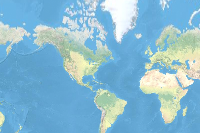

In [11]:
import math, time, json
from arcgis.gis import Item
from arcgis.features import FeatureLayer, FeatureSet
from arcgis.geometry import Envelope, Geometry

# ---------------------------------------------------------------------------
# Auto-tile: if the extent exceeds the 15000×15000 pixel server limit,
# split into smaller tiles, run each sequentially, merge, and clean up.
# ---------------------------------------------------------------------------
MAX_PIXELS = 15000

def _build_tiles(extent, cell_size):
    """Split extent into tiles that each fit within MAX_PIXELS × MAX_PIXELS."""
    xmin, ymin = extent["xmin"], extent["ymin"]
    xmax, ymax = extent["xmax"], extent["ymax"]
    sr = extent.get("spatialReference", {})
    width, height = xmax - xmin, ymax - ymin
    cols = math.ceil(width / cell_size)
    rows = math.ceil(height / cell_size)
    if cols <= MAX_PIXELS and rows <= MAX_PIXELS:
        return [extent]
    n_tiles_x = math.ceil(cols / MAX_PIXELS)
    n_tiles_y = math.ceil(rows / MAX_PIXELS)
    tile_w, tile_h = width / n_tiles_x, height / n_tiles_y
    tiles = []
    for ty in range(n_tiles_y):
        for tx in range(n_tiles_x):
            tiles.append({
                "xmin": xmin + tx * tile_w, "ymin": ymin + ty * tile_h,
                "xmax": xmin + (tx + 1) * tile_w, "ymax": ymin + (ty + 1) * tile_h,
                "spatialReference": sr,
            })
    return tiles

def _get_result_item(result):
    """Resolve a FeatureLayer result to its parent Item."""
    if isinstance(result, Item):
        return result
    if isinstance(result, FeatureLayer):
        sid = getattr(result.properties, "serviceItemId", None)
        if sid:
            return gis.content.get(sid)
        url = result.url
        if "/services/" in url:
            svc_url = url.rsplit("/", 1)[0]
            import requests as _rq
            info = _rq.get(f"{svc_url}?f=json&token={gis._con.token}", timeout=15).json()
            sid = info.get("serviceItemId", "")
            if sid:
                return gis.content.get(sid)
    return result

# ── Build tiles ───────────────────────────────────────────────────────────
cs = processing_cell_size or 0.239
tiles = _build_tiles(analysis_extent, cs)
n_tiles = len(tiles)

print("Running Detect Objects Using Deep Learning...")
print(f"  Imagery: {imagery_item.title}")
print(f"  Model:   {model_item.title}")
print(f"  Output:  {output_title} (staging)")
if n_tiles > 1:
    print(f"  Tiles:   {n_tiles} (each ≤ {MAX_PIXELS}×{MAX_PIXELS} px)")
print()

n_to_run = n_tiles
tiles_to_run = tiles

if True:
    # ── Run each new tile ──────────────────────────────────────────────
    print(f"\n  Processing {n_to_run} tile(s)...")
    tile_items = []
    for i, tile_ext in enumerate(tiles_to_run):
        tile_ctx = {"extent": tile_ext}
        if processing_cell_size is not None:
            tile_ctx["cellSize"] = processing_cell_size

        tile_name = f"{output_title}_tile{i+1}of{n_to_run}" if n_to_run > 1 else output_title
        label = f"Tile {i+1}/{n_to_run}" if n_to_run > 1 else "Analysis"
        print(f"  [{label}] '{tile_name}' ... ", end="", flush=True)
        t0 = time.time()

        raw = gis._tools.rasteranalysis.detect_objects_using_deep_learning(
            input_raster=imagery_layer,
            model=model_item,
            output_objects=tile_name,
            model_arguments=model_arguments if model_arguments else None,
            context=tile_ctx,
        )
        item = _get_result_item(raw)
        elapsed = time.time() - t0
        print(f"done ({elapsed:.0f}s)")
        tile_items.append(item)

    # ── Merge tiles into a single staging layer ──────────────────────
    # Raw detections are NEVER appended directly to the target layer.
    # They go into a temporary staging item so QA/QC can run first.
    # After QA/QC, the publish step handles the final append/create.
    if n_to_run == 1:
        detect_result = tile_items[0]
        # Rename to make it clear this is a staging layer
        _staging_title = f"{output_title} (staging)"
        detect_result.update(item_properties={"title": _staging_title})
        detect_result = gis.content.get(detect_result.itemid)
    else:
        # Merge all tiles into the first tile item
        base_item = tile_items[0]
        base_lyr = base_item.layers[0]
        print(f"\nMerging {n_to_run} tiles into staging layer...")

        for idx, ti in enumerate(tile_items[1:], start=2):
            lyr = ti.layers[0] if isinstance(ti, Item) else ti
            tile_fs = lyr.query(where="1=1")
            n_feats = len(tile_fs.features)
            print(f"  Appending tile {idx}/{n_to_run}: {n_feats} features ... ", end="", flush=True)
            result = base_lyr.edit_features(adds=tile_fs.features)
            add_count = sum(1 for r in result.get("addResults", []) if r.get("success"))
            print(f"added {add_count}")

        # Rename the merged item
        _staging_title = f"{output_title} (staging)"
        base_item.update(item_properties={"title": _staging_title})
        detect_result = gis.content.get(base_item.itemid)
        print(f"  Staging layer: {detect_result.title}")

        # Delete intermediate tile items (not the base)
        print(f"  Deleting {len(tile_items) - 1} intermediate items...")
        for ti in tile_items[1:]:
            try:
                if isinstance(ti, Item):
                    ti.delete(permanent=True)
            except Exception as e:
                print(f"    ⚠️  {e}")
        print("  Cleanup done.")

_title = getattr(detect_result, "title", output_title)
_iid = getattr(detect_result, "itemid", "?")
_url = getattr(detect_result, "url", "?")
_total = detect_result.layers[0].query(return_count_only=True) if hasattr(detect_result, "layers") else "?"
print(f"\nDone! {_title}")
print(f"  Item ID:        {_iid}")
print(f"  URL:            {_url}")
print(f"  Total features: {_total}")
print(f"\n  ℹ Raw detections are in a STAGING layer.")
print(f"  Run QA/QC, then use the publish step to create a new layer or append to an existing one.")
detect_result

## Step 8 – Display Results

The detected objects are added to the map as a Feature Layer. You can also query the results as a spatially enabled DataFrame for further analysis.

In [12]:
# Display detection results on a fresh map
result_map = gis.map()
result_map.basemap.basemap = "satellite"
result_map.extent = analysis_extent
result_map.content.add(imagery_layer)
result_map.content.add(detect_result)
result_map

Map()

In [13]:
# Query detection results as a spatially enabled DataFrame
result_layer = detect_result.layers[0]
sdf = result_layer.query(where="1=1").sdf
print(f"{len(sdf)} objects detected")
sdf.head(10)

1100 objects detected


,OID,Class,Confidence,SHAPE
0,1,tree,0.565483,"{""rings"": [[[84373.2894897461, 455169.09332275..."
1,2,tree,0.571754,"{""rings"": [[[84392.0894775428, 455269.69329833..."
2,3,tree,0.715026,"{""rings"": [[[84369.0894775391, 455272.49328613..."
3,4,tree,0.833853,"{""rings"": [[[84296.8895263709, 455288.09332275..."
4,5,tree,0.530168,"{""rings"": [[[84398.0894775428, 455259.49328613..."
5,6,tree,0.605628,"{""rings"": [[[84277.0894775465, 455147.69329834..."
6,7,tree,0.546458,"{""rings"": [[[84269.6895141639, 455145.29327393..."
7,8,tree,0.720077,"{""rings"": [[[84278.6895141602, 455145.29327393..."
8,9,tree,0.699068,"{""rings"": [[[84242.2894897498, 455275.29327392..."
9,10,tree,0.56937,"{""rings"": [[[84270.8895263672, 455213.49328614..."


## Step 9 – Geometric QA/QC

Select a **QA/QC tool** from the dropdown and adjust parameters. Each tool lives in the `qaqc/` package and converts raw DL polygons into clean geometries.

### Tree Circles (`qaqc.tree`)
For elongated detections (shadow + trunk), the tool estimates a **global shadow azimuth** from all elongated shapes — the vector from the narrow (shadow tip) end to the wide (canopy) end. The median direction gives a robust sun bearing for the scene.

| Detection shape | Centre | Radius |
|---|---|---|
| **Circular** (elong ≤ threshold) | Polygon centroid | √(area / π) |
| **Elongated** (shadow + trunk) | Centroid shifted toward sun by `canopy_shift × major` | minor / 2 |

In [14]:
import sys, os, importlib
import ipywidgets as widgets
from IPython.display import display
from arcgis.gis import Item

# Ensure the repo root is on sys.path so `qaqc` can be imported
_repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if _repo_root not in sys.path:
    sys.path.insert(0, _repo_root)

import qaqc
importlib.reload(qaqc)  # pick up any edits

# ── QA/QC tool dropdown ──────────────────────────────────────────────────
_tool_dropdown = widgets.Dropdown(
    options=list(qaqc.TOOLS.keys()),
    value=list(qaqc.TOOLS.keys())[0],
    description="QA/QC Tool:",
    layout=widgets.Layout(width="300px"),
)

# ── Dynamic parameter widgets per tool ───────────────────────────────────
_param_box = widgets.VBox()

def _build_param_widgets(tool_label):
    """Load the selected tool module and build parameter widgets."""
    mod_path = qaqc.TOOLS[tool_label]
    mod = importlib.import_module(mod_path)
    importlib.reload(mod)
    pw = {}
    rows = []
    for pi in mod.PARAM_INFO:
        name = pi["name"]
        default = mod.DEFAULTS[name]
        w = widgets.FloatText(value=default, description=pi["label"],
                              style={"description_width": "200px"},
                              layout=widgets.Layout(width="350px"))
        w._qaqc_desc = pi.get("description", "")
        pw[name] = w
        rows.append(widgets.HBox([w, widgets.Label(value=pi.get("description", ""),
                                                     layout=widgets.Layout(width="400px"))]))
    _param_box.children = rows
    return mod, pw

def _on_tool_change(change):
    _build_param_widgets(change["new"])

_tool_dropdown.observe(_on_tool_change, names="value")

# Build initial widgets
_active_mod, _active_pw = _build_param_widgets(_tool_dropdown.value)

display(_tool_dropdown)
display(_param_box)
print("\nAdjust parameters above, then run the next cell to execute.")

Dropdown(description='QA/QC Tool:', layout=Layout(width='300px'), options=('Tree Points',), value='Tree Points…


Adjust parameters above, then run the next cell to execute.


In [15]:
import importlib

# Reload the selected tool (pick up any code edits)
mod_path = qaqc.TOOLS[_tool_dropdown.value]
_active_mod = importlib.import_module(mod_path)
importlib.reload(_active_mod)

# Read parameter values from widgets
_run_params = {name: w.value for name, w in _active_pw.items()}

# Get features from detect_result
result_lyr = detect_result.layers[0] if isinstance(detect_result, Item) else detect_result
fs = result_lyr.query(where="1=1")
layer_sr = dict(result_lyr.properties.extent.spatialReference)

print(f"Running QA/QC: {_tool_dropdown.value}")
print(f"  Raw features: {len(fs.features)}")
print(f"  Spatial ref:  {layer_sr}")
print(f"  Params:       {_run_params}")
print()

# Run the tool
tree_fset, tree_info = _active_mod.run(fs.features, layer_sr, **_run_params)
tree_sdf = tree_fset.sdf

# Print results
print(f"Result: {tree_info['tree_count']} trees  (from {tree_info['raw_count']} raw detections)")
print(f"  Circular:      {tree_info['circular']}")
print(f"  Shadow+trunk:  {tree_info['shadow_trunk']}")
print(f"  Clusters:      {tree_info['clusters']}")
if tree_info.get("shadow_azimuth_deg") is not None:
    print(f"  Shadow azimuth: {tree_info['shadow_azimuth_deg']}° (toward sun, CW from N)")
if len(tree_sdf):
    print(f"  Radius range:  {tree_sdf.radius_m.min():.1f} – {tree_sdf.radius_m.max():.1f} m")
tree_sdf.head(10)

Running QA/QC: Tree Points
  Raw features: 1100
  Spatial ref:  {'wkid': 28992, 'latestWkid': 28992}
  Params:       {'cluster_dist': 5.0, 'elongation_threshold': 1.8, 'min_radius': 1.0, 'max_radius': 15.0, 'canopy_shift': 0.3}

Result: 994 trees  (from 1100 raw detections)
  Circular:      749
  Shadow+trunk:  245
  Clusters:      994
  Shadow azimuth: 344.0° (toward sun, CW from N)
  Radius range:  1.1 – 14.0 m


,tree_id,radius_m,canopy_width_m,elongation,det_type,orig_area_m2,cluster_size,OBJECTID,SHAPE
0,1,14.04,28.08,1.14,circular,619.36,1,1,"{""x"": 85217.2920916208, ""y"": 454667.3460877642..."
1,2,12.52,25.04,1.1,circular,492.6,1,2,"{""x"": 84948.18626336344, ""y"": 454439.884713578..."
2,3,11.59,23.17,1.2,circular,421.76,1,3,"{""x"": 84950.0895436682, ""y"": 454476.7569150989..."
3,4,10.95,21.91,1.19,circular,377.0,1,4,"{""x"": 84368.49821112331, ""y"": 455181.433880335..."
4,5,10.83,21.66,1.08,circular,368.4,2,5,"{""x"": 84440.0821401904, ""y"": 455110.3014816401..."
5,6,10.57,21.13,1.22,circular,350.68,1,6,"{""x"": 84874.56416546246, ""y"": 454778.336876753..."
6,7,7.72,15.43,1.81,shadow_trunk,340.04,1,7,"{""x"": 84412.57822451662, ""y"": 454408.713735495..."
7,8,9.9,19.79,1.06,circular,307.6,2,8,"{""x"": 84579.71023187744, ""y"": 455059.110646093..."
8,9,9.53,19.06,1.35,circular,285.36,1,9,"{""x"": 85046.7080522083, ""y"": 455210.8777419550..."
9,10,9.39,18.78,1.38,circular,277.08,1,10,"{""x"": 84872.75486236306, ""y"": 454327.882767878..."


In [16]:
# Display QA/QC results on a fresh map — small point markers
qaqc_map = gis.map()
qaqc_map.basemap.basemap = "satellite"
qaqc_map.extent = analysis_extent
qaqc_map.content.add(imagery_layer)

# Use a small simple-marker symbol so points look like dots, not circles
_pt_renderer = {
    "type": "simple",
    "symbol": {
        "type": "esriSMS",
        "style": "esriSMSCircle",
        "color": [0, 255, 255, 200],
        "size": 6,
        "outline": {"color": [255, 255, 255, 255], "width": 1},
    },
}
qaqc_map.content.add(tree_fset, drawing_info={"renderer": _pt_renderer})
qaqc_map

Map()

In [18]:
import re
import time
from arcgis.gis import Item
from arcgis.features import Feature, FeatureLayerCollection
import ipywidgets as widgets
from IPython.display import display

if "tree_sdf" not in globals() or tree_sdf is None or len(tree_sdf) == 0:
    if "tree_fset" not in globals() or not tree_fset.features:
        raise ValueError("tree_fset is empty. Run the QA/QC cell first.")
    tree_sdf = tree_fset.sdf

# ── Publish mode selection ─────────────────────────────────────────────
_publish_mode_w = widgets.Dropdown(
    options=["Create new layer", "Append to existing layer"],
    value="Create new layer",
    description="Mode:",
    layout=widgets.Layout(width="350px"),
)

_default_publish_title = f"{output_title} QAQC"
_title_w = widgets.Text(
    value=_default_publish_title,
    description="Title:",
    layout=widgets.Layout(width="450px"),
)

# ── Folder selection (for Create new layer) ────────────────────────────
_user_folders = gis.users.me.folders
# folders may be dicts (arcgis 2.x) or objects — handle both
_folder_names = []
for _f in _user_folders:
    _fn = (_f.get("title") or _f.get("name")) if isinstance(_f, dict) else (getattr(_f, "title", None) or getattr(_f, "name", None))
    _folder_names.append(_fn or str(_f))

_folder_mode_w = widgets.Dropdown(
    options=["Root (no folder)", "Existing folder", "Create new folder"],
    value="Root (no folder)",
    description="Folder:",
    layout=widgets.Layout(width="350px"),
)
_existing_folder_w = widgets.Dropdown(
    options=_folder_names if _folder_names else ["(no folders)"],
    description="Select:",
    layout=widgets.Layout(width="400px"),
)
_new_folder_w = widgets.Text(
    value="",
    placeholder="Enter new folder name",
    description="Name:",
    layout=widgets.Layout(width="400px"),
)

# ── Existing layer ID (for Append mode) ───────────────────────────────
_existing_id_w = widgets.Text(
    value="",
    placeholder="Existing layer Item ID",
    description="Item ID:",
    layout=widgets.Layout(width="450px"),
)

# ── Dynamic container — swap children instead of toggling display ─────
# (VS Code notebooks can block input on widgets initially hidden via
#  layout.display="none", so we rebuild the VBox children on change.)
_options_box = widgets.VBox([_title_w, _folder_mode_w])

def _rebuild_options(mode):
    if mode == "Append to existing layer":
        _options_box.children = [_existing_id_w]
    else:
        folder_children = [_folder_mode_w]
        fm = _folder_mode_w.value
        if fm == "Existing folder":
            folder_children.append(_existing_folder_w)
        elif fm == "Create new folder":
            folder_children.append(_new_folder_w)
        _options_box.children = [_title_w] + folder_children

def _on_mode_change(change):
    _rebuild_options(change["new"])

def _on_folder_mode_change(change):
    _rebuild_options(_publish_mode_w.value)

_publish_mode_w.observe(_on_mode_change, names="value")
_folder_mode_w.observe(_on_folder_mode_change, names="value")

print("Select publish mode then run the next cell:")
display(widgets.VBox([_publish_mode_w, _options_box]))
#645b16a4364a443f9ca5a9b8efa0e93f

Select publish mode then run the next cell:


In [19]:
publish_title = _title_w.value.strip() or _default_publish_title
publish_mode = _publish_mode_w.value

# ── Resolve folder ─────────────────────────────────────────────────────
_publish_folder = None
if publish_mode == "Create new layer":
    if _folder_mode_w.value == "Existing folder":
        _sel_name = _existing_folder_w.value
        _publish_folder = _sel_name
    elif _folder_mode_w.value == "Create new folder":
        _new_name = _new_folder_w.value.strip()
        if _new_name:
            gis.content.create_folder(_new_name)
            _publish_folder = _new_name
            print(f"Created folder: {_new_name}")

def _sanitize_service_name(value: str) -> str:
    name = re.sub(r"[^0-9A-Za-z_]+", "_", value).strip("_")
    if not name:
        name = "qaqc_results"
    if name[0].isdigit():
        name = f"fs_{name}"
    return name[:80]

# Build features from tree_fset (already Point geometry from QA/QC)
# Exclude geometry/system fields that conflict with the hosted layer schema
_SKIP_ATTRS = {"shape", "objectid", "fid", "oid", "globalid", "shape_length", "shape_area",
               "shape__length", "shape__area", "st_length(shape)", "st_area(shape)"}

_publish_features = []
for feat in tree_fset.features:
    geom = feat.geometry if isinstance(feat.geometry, dict) else dict(feat.geometry)
    attrs = dict(feat.attributes) if feat.attributes else {}
    # Strip system/geometry columns and convert numpy types to native Python
    attrs = {k: (v.item() if hasattr(v, 'item') else v)
             for k, v in attrs.items() if k.lower() not in _SKIP_ATTRS}
    _publish_features.append(Feature(geometry=geom, attributes=attrs))

if publish_mode == "Append to existing layer":
    # ── Append mode ────────────────────────────────────────────────────
    _target_id = _existing_id_w.value.strip()
    if not _target_id:
        raise ValueError("Provide an existing layer Item ID.")
    _target_item = gis.content.get(_target_id)
    if _target_item is None:
        raise ValueError(f"Item '{_target_id}' not found.")
    _target_lyr = _target_item.layers[0]

    BATCH = 500
    total_added = 0
    for i in range(0, len(_publish_features), BATCH):
        batch = _publish_features[i : i + BATCH]
        result = _target_lyr.edit_features(adds=batch)
        added = sum(1 for r in result.get("addResults", []) if r.get("success"))
        total_added += added
        print(f"  Batch {i // BATCH + 1}: {added}/{len(batch)} added")

    published_item_id = _target_id
    published_tree_layer = _target_item
    print(f"\nAppended {total_added} features to: {_target_item.title}")
    print(f"Item ID: {published_item_id}")

else:
    # ── Create new layer via create_service + edit_features ────────────
    # (Avoids SeDF.to_featurelayer which requires pyshp/gdal/arcpy)
    service_name = f"{_sanitize_service_name(publish_title)}_{int(time.time())}"

    # Field definitions inferred from tree feature attributes
    import numpy as _np
    _type_map = {
        int: "esriFieldTypeDouble", float: "esriFieldTypeDouble", str: "esriFieldTypeString",
        _np.int64: "esriFieldTypeDouble", _np.int32: "esriFieldTypeInteger",
        _np.float64: "esriFieldTypeDouble", _np.float32: "esriFieldTypeDouble",
    }
    _sample_attrs = _publish_features[0].attributes if _publish_features else {}
    _fields = [
        {"name": "objectid", "type": "esriFieldTypeOID", "alias": "OBJECTID", "sqlType": "sqlTypeOther"},
    ]
    for fname, fval in _sample_attrs.items():
        if fname.lower() in _SKIP_ATTRS:
            continue
        # Skip geometry objects that slipped into attributes
        if hasattr(fval, 'spatialReference') or hasattr(fval, 'rings'):
            continue
        ft = _type_map.get(type(fval), "esriFieldTypeString")
        fd = {"name": fname, "type": ft, "alias": fname, "sqlType": "sqlTypeOther"}
        if ft == "esriFieldTypeString":
            fd["length"] = 256
        _fields.append(fd)

    # Determine spatial reference from features
    _sample_geom = _publish_features[0].geometry if _publish_features else {}
    _sr = _sample_geom.get("spatialReference", {"wkid": 102100, "latestWkid": 3857})

    # Create the empty hosted feature service
    _service_item = gis.content.create_service(
        name=service_name,
        service_type="featureService",
        folder=_publish_folder,
    )
    _service_item.update(item_properties={
        "title": publish_title,
        "tags": "ArcGIS API for Python, QAQC, Deep Learning",
        "snippet": f"QA/QC tree points from {output_title}",
    })

    # Add layer definition
    _flc = FeatureLayerCollection.fromitem(_service_item)
    _layer_def = {
        "layers": [{
            "name": publish_title,
            "geometryType": "esriGeometryPoint",
            "objectIdField": "objectid",
            "type": "Feature Layer",
            "fields": _fields,
            "extent": {
                "xmin": -20037508.34, "ymin": -20037508.34,
                "xmax": 20037508.34, "ymax": 20037508.34,
                "spatialReference": _sr,
            },
            "capabilities": "Create,Query,Update,Delete,Editing",
            "hasAttachments": False,
        }],
    }
    _flc.manager.add_to_definition(_layer_def)

    # Wait for layer to propagate
    time.sleep(5)
    _service_item = gis.content.get(_service_item.itemid)
    _flc = FeatureLayerCollection.fromitem(_service_item)
    _target_lyr = _flc.layers[0]

    # Add features in batches
    BATCH = 500
    total_added = 0
    for i in range(0, len(_publish_features), BATCH):
        batch = _publish_features[i : i + BATCH]
        result = _target_lyr.edit_features(adds=batch)
        added = sum(1 for r in result.get("addResults", []) if r.get("success"))
        total_added += added
        print(f"  Batch {i // BATCH + 1}: {added}/{len(batch)} added")

    published_item_id = _service_item.itemid
    published_tree_layer = _service_item
    print(f"Created hosted feature layer: {publish_title}")
    print(f"Features published: {total_added}/{len(_publish_features)}")
    print(f"Item ID: {published_item_id}")

# ── Clean up the staging layer (raw detections) ───────────────────────
# The staging layer was created during detection to hold raw results
# before QA/QC. Now that cleaned data is published, delete it.
if "detect_result" in globals() and isinstance(detect_result, Item):
    _staging_title = getattr(detect_result, "title", "")
    if "(staging)" in _staging_title:
        try:
            detect_result.delete(permanent=True)
            print(f"\n✓ Deleted staging layer: {_staging_title}")
        except Exception as e:
            print(f"\n⚠ Could not delete staging layer: {e}")

published_item_id

  Batch 1: 500/500 added
  Batch 2: 494/494 added
Created hosted feature layer: SAM3 Trees Voorburg 20 cm QAQC
Features published: 994/994
Item ID: 7b4af64f16a04410a135bc8f314a4347

✓ Deleted staging layer: SAM3 Trees Voorburg 20 cm (staging)


'7b4af64f16a04410a135bc8f314a4347'

In [ ]:
publish_title = _title_w.value.strip() or _default_publish_title
publish_mode = _publish_mode_w.value

# ── Resolve folder ─────────────────────────────────────────────────────
_publish_folder = None
if publish_mode == "Create new layer":
    if _folder_mode_w.value == "Existing folder":
        _sel_name = _existing_folder_w.value
        _publish_folder = _sel_name
    elif _folder_mode_w.value == "Create new folder":
        _new_name = _new_folder_w.value.strip()
        if _new_name:
            gis.content.create_folder(_new_name)
            _publish_folder = _new_name
            print(f"Created folder: {_new_name}")

def _sanitize_service_name(value: str) -> str:
    name = re.sub(r"[^0-9A-Za-z_]+", "_", value).strip("_")
    if not name:
        name = "qaqc_results"
    if name[0].isdigit():
        name = f"fs_{name}"
    return name[:80]

# Build features from tree_fset (already Point geometry from QA/QC)
# Exclude geometry/system fields that conflict with the hosted layer schema
_SKIP_ATTRS = {"shape", "objectid", "fid", "oid", "globalid", "shape_length", "shape_area",
               "shape__length", "shape__area", "st_length(shape)", "st_area(shape)"}

_publish_features = []
for feat in tree_fset.features:
    geom = feat.geometry if isinstance(feat.geometry, dict) else dict(feat.geometry)
    attrs = dict(feat.attributes) if feat.attributes else {}
    # Strip system/geometry columns and convert numpy types to native Python
    attrs = {k: (v.item() if hasattr(v, 'item') else v)
             for k, v in attrs.items() if k.lower() not in _SKIP_ATTRS}
    _publish_features.append(Feature(geometry=geom, attributes=attrs))

if publish_mode == "Append to existing layer":
    # ── Append mode ────────────────────────────────────────────────────
    _target_id = _existing_id_w.value.strip()
    if not _target_id:
        raise ValueError("Provide an existing layer Item ID.")
    _target_item = gis.content.get(_target_id)
    if _target_item is None:
        raise ValueError(f"Item '{_target_id}' not found.")
    _target_lyr = _target_item.layers[0]

    BATCH = 500
    total_added = 0
    for i in range(0, len(_publish_features), BATCH):
        batch = _publish_features[i : i + BATCH]
        result = _target_lyr.edit_features(adds=batch)
        added = sum(1 for r in result.get("addResults", []) if r.get("success"))
        total_added += added
        print(f"  Batch {i // BATCH + 1}: {added}/{len(batch)} added")

    published_item_id = _target_id
    published_tree_layer = _target_item
    print(f"\nAppended {total_added} features to: {_target_item.title}")
    print(f"Item ID: {published_item_id}")

else:
    # ── Create new layer via create_service + edit_features ────────────
    # (Avoids SeDF.to_featurelayer which requires pyshp/gdal/arcpy)
    service_name = f"{_sanitize_service_name(publish_title)}_{int(time.time())}"

    # Field definitions inferred from tree feature attributes
    import numpy as _np
    _type_map = {
        int: "esriFieldTypeDouble", float: "esriFieldTypeDouble", str: "esriFieldTypeString",
        _np.int64: "esriFieldTypeDouble", _np.int32: "esriFieldTypeInteger",
        _np.float64: "esriFieldTypeDouble", _np.float32: "esriFieldTypeDouble",
    }
    _sample_attrs = _publish_features[0].attributes if _publish_features else {}
    _fields = [
        {"name": "objectid", "type": "esriFieldTypeOID", "alias": "OBJECTID", "sqlType": "sqlTypeOther"},
    ]
    for fname, fval in _sample_attrs.items():
        if fname.lower() in _SKIP_ATTRS:
            continue
        # Skip geometry objects that slipped into attributes
        if hasattr(fval, 'spatialReference') or hasattr(fval, 'rings'):
            continue
        ft = _type_map.get(type(fval), "esriFieldTypeString")
        fd = {"name": fname, "type": ft, "alias": fname, "sqlType": "sqlTypeOther"}
        if ft == "esriFieldTypeString":
            fd["length"] = 256
        _fields.append(fd)

    # Determine spatial reference from features
    _sample_geom = _publish_features[0].geometry if _publish_features else {}
    _sr = _sample_geom.get("spatialReference", {"wkid": 102100, "latestWkid": 3857})

    # Create the empty hosted feature service
    _service_item = gis.content.create_service(
        name=service_name,
        service_type="featureService",
        folder=_publish_folder,
    )
    _service_item.update(item_properties={
        "title": publish_title,
        "tags": "ArcGIS API for Python, QAQC, Deep Learning",
        "snippet": f"QA/QC tree points from {output_title}",
    })

    # Add layer definition
    _flc = FeatureLayerCollection.fromitem(_service_item)
    _layer_def = {
        "layers": [{
            "name": publish_title,
            "geometryType": "esriGeometryPoint",
            "objectIdField": "objectid",
            "type": "Feature Layer",
            "fields": _fields,
            "extent": {
                "xmin": -20037508.34, "ymin": -20037508.34,
                "xmax": 20037508.34, "ymax": 20037508.34,
                "spatialReference": _sr,
            },
            "capabilities": "Create,Query,Update,Delete,Editing",
            "hasAttachments": False,
        }],
    }
    _flc.manager.add_to_definition(_layer_def)

    # Wait for layer to propagate
    time.sleep(5)
    _service_item = gis.content.get(_service_item.itemid)
    _flc = FeatureLayerCollection.fromitem(_service_item)
    _target_lyr = _flc.layers[0]

    # Add features in batches
    BATCH = 500
    total_added = 0
    for i in range(0, len(_publish_features), BATCH):
        batch = _publish_features[i : i + BATCH]
        result = _target_lyr.edit_features(adds=batch)
        added = sum(1 for r in result.get("addResults", []) if r.get("success"))
        total_added += added
        print(f"  Batch {i // BATCH + 1}: {added}/{len(batch)} added")

    published_item_id = _service_item.itemid
    published_tree_layer = _service_item
    print(f"Created hosted feature layer: {publish_title}")
    print(f"Features published: {total_added}/{len(_publish_features)}")
    print(f"Item ID: {published_item_id}")

# ── Clean up the staging layer (raw detections) ───────────────────────
# The staging layer was created during detection to hold raw results
# before QA/QC. Now that cleaned data is published, delete it.
if "detect_result" in globals() and isinstance(detect_result, Item):
    _staging_title = getattr(detect_result, "title", "")
    if "(staging)" in _staging_title:
        try:
            detect_result.delete(permanent=True)
            print(f"\n✓ Deleted staging layer: {_staging_title}")
        except Exception as e:
            print(f"\n⚠ Could not delete staging layer: {e}")

published_item_id

  Batch 1: 500/500 added
  Batch 2: 494/494 added
Created hosted feature layer: SAM3 Trees Voorburg 20 cm QAQC
Features published: 994/994
Item ID: 7b4af64f16a04410a135bc8f314a4347

✓ Deleted staging layer: SAM3 Trees Voorburg 20 cm (staging)


'7b4af64f16a04410a135bc8f314a4347'